In [12]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from collections import defaultdict

In [10]:

# media_bias_results.json — dict format: {domain: {...data...}}
with open("media_bias_results.json", encoding="utf-8") as f:
    data = json.load(f)

# media_bias_results2.json — JSONL format: one {"outlet": domain, "data": {...}} per line
with open("media_bias_results2.json", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        record = json.loads(line)
        data[record["outlet"]] = record["data"]

print(list(data.keys())[0])
print(len(data))

en.wikipedia.org
2010


In [14]:
def count_total_domains_per_model(filename="data/domains/prompt_id_links_clsf.json"):
    annotations = pd.read_csv("data_prompts/man-annotated-train-high-risk.csv")
    prompt_id_to_domain = dict(zip(annotations["prompt_id"], annotations["annotation"]))
    with open(filename, "r") as f:
        data = json.load(f)
    results = {"Factual": defaultdict(int), "Analytical": defaultdict(int)}
    for model in data:
        for prompt_id in data[model]:
            urls = data[model][prompt_id]
            for url, url_data in urls.items():
                if prompt_id_to_domain[prompt_id] == "Factual":
                    results["Factual"][model]+= urls[url]["count"]      
                elif prompt_id_to_domain[prompt_id] == "Analytical":
                    results["Analytical"][model]+= urls[url]["count"]
                else:
                    print(f"Warning: prompt_id {prompt_id} has unknown domain {prompt_id_to_domain[prompt_id]}")
    return results
count_total_domains_per_model()

{'Factual': defaultdict(int,
             {'gpt-5.4': 3023, 'gemini': 8221, 'claude-sonnet-4-6': 11201}),
 'Analytical': defaultdict(int,
             {'gpt-5.4': 4771, 'gemini': 10162, 'claude-sonnet-4-6': 18262})}

In [25]:

def counts_by_credibility(mbfc_data, score_column="MBFC Credibility Rating",
                          links_file="data/domains/prompt_id_links_clsf.json"):
    with open(links_file) as f:
        links = json.load(f)

    models = list(links.keys())

    # First pass: collect weighted counts and unique domains per model
    all_counts = {}
    all_unique = {}
    for model in models:
        counts = defaultdict(int)
        unique = defaultdict(set)
        for prompt_id, urls in links[model].items():
            for domain, url_data in urls.items():
                if domain not in mbfc_data:
                    continue
                info = mbfc_data[domain]
                if score_column not in info:
                    continue
                rating = info[score_column]
                if score_column in ("Factual Reporting", "Bias Rating"):
                    rating = rating.split("(")[0].strip()
                counts[rating] += url_data["count"]
                unique[rating].add(domain)
        all_counts[model] = counts
        all_unique[model] = unique

    # Print unique source counts per category per model
    all_ratings = sorted({r for counts in all_counts.values() for r in counts})
    for model in models:
        print(f"\n{model}")
        for rating in all_ratings:
            n = len(all_unique[model].get(rating, set()))
            if n:
                print(f"  {rating}: {n} unique source(s)")

    # Build a stable color mapping across all ratings
    pastel = plt.get_cmap("Pastel1").colors
    color_map = {rating: pastel[i % len(pastel)] for i, rating in enumerate(all_ratings)}

    fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 5))
    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        counts = all_counts[model]
        labels = list(counts.keys())
        sizes = list(counts.values())
        colors = [color_map[label] for label in labels]

        ax.bar(labels, sizes, color=colors)
        ax.set_title(model)
        ax.set_ylabel("Citation count")
        ax.set_xlabel(score_column)
        ax.tick_params(axis="x", rotation=45)

    fig.suptitle(f"{score_column} by Model (weighted by citation count)", fontsize=14)
    plt.tight_layout()
    plt.show()



gpt-5.4
  HIGH CREDIBILITY: 97 unique source(s)
  LOW CREDIBILITY: 6 unique source(s)
  MEDIUM CREDIBILITY: 22 unique source(s)

gemini
  HIGH CREDIBILITY: 314 unique source(s)
  LOW CREDIBILITY: 39 unique source(s)
  MEDIUM CREDIBILITY: 52 unique source(s)
  N/A: 1 unique source(s)

claude-sonnet-4-6
  HIGH CREDIBILITY: 505 unique source(s)
  LOW CREDIBILITY: 72 unique source(s)
  MEDIUM CREDIBILITY: 88 unique source(s)
  N/A: 2 unique source(s)


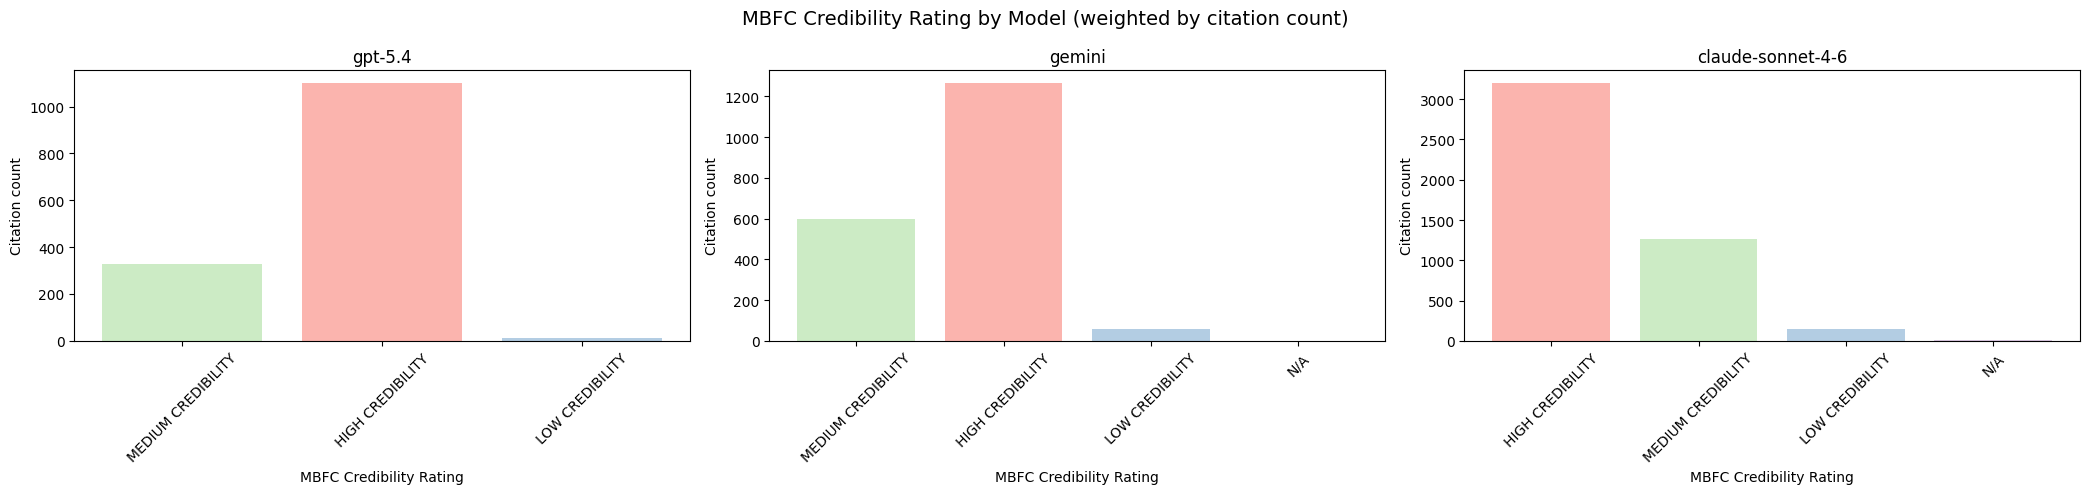

In [26]:
counts_by_credibility(data, score_column="MBFC Credibility Rating")


gpt-5.4
  HIGH: 83 unique source(s)
  MIXED: 16 unique source(s)
  MOSTLY FACTUAL: 18 unique source(s)
  VERY HIGH: 7 unique source(s)
  VERY LOW: 1 unique source(s)

gemini
  HIGH: 267 unique source(s)
  LOW: 7 unique source(s)
  MIXED: 64 unique source(s)
  MOSTLY FACTUAL: 37 unique source(s)
  N/A: 1 unique source(s)
  VERY HIGH: 20 unique source(s)
  VERY LOW: 8 unique source(s)
  VERY- HIGH: 2 unique source(s)

claude-sonnet-4-6
  HIGH: 413 unique source(s)
  LOW: 18 unique source(s)
  MIXED: 100 unique source(s)
  MOSTLY FACTUAL: 82 unique source(s)
  N/A: 2 unique source(s)
  VERY HIGH: 37 unique source(s)
  VERY LOW: 10 unique source(s)
  VERY- HIGH: 5 unique source(s)


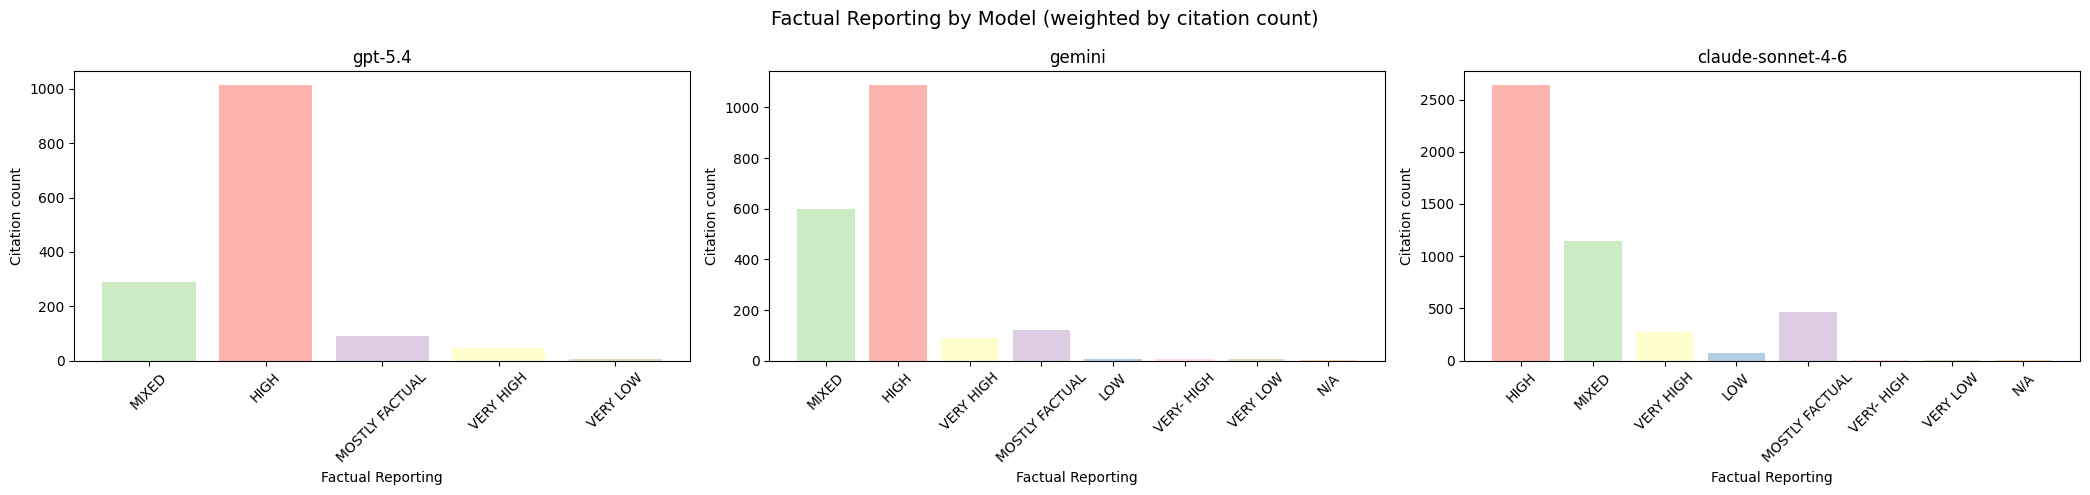

In [27]:
counts_by_credibility(data, score_column="Factual Reporting")


gpt-5.4
  EXTREME RIGHT: 1 unique source(s)
  LEAST BIASED: 30 unique source(s)
  LEFT: 9 unique source(s)
  LEFT-CENTER: 28 unique source(s)
  LEFT-CENTER PRO-SCIENCE: 1 unique source(s)
  PRO-SCIENCE: 38 unique source(s)
  RIGHT: 5 unique source(s)
  RIGHT-CENTER: 13 unique source(s)

gemini
  EXTREME RIGHT: 2 unique source(s)
  FAR LEFT: 6 unique source(s)
  FAR RIGHT: 1 unique source(s)
  FAR- LEFT: 1 unique source(s)
  FAR-LEFT: 1 unique source(s)
  LEAST BIASED: 100 unique source(s)
  LEFT: 28 unique source(s)
  LEFT-CENTER: 110 unique source(s)
  PRO- SCIENCE: 3 unique source(s)
  PRO-SCIENCE: 69 unique source(s)
  PRO-SCIENCE / LEAST BIASED: 1 unique source(s)
  RIGHT: 21 unique source(s)
  RIGHT -CENTER: 2 unique source(s)
  RIGHT CONSPIRACY-PSEUDOSCIENCE: 2 unique source(s)
  RIGHT-CENTER: 58 unique source(s)
  SATIRE: 1 unique source(s)

claude-sonnet-4-6
  EXTREME RIGHT: 9 unique source(s)
  FAR LEFT: 7 unique source(s)
  FAR RIGHT: 5 unique source(s)
  FAR-LEFT: 1 unique 

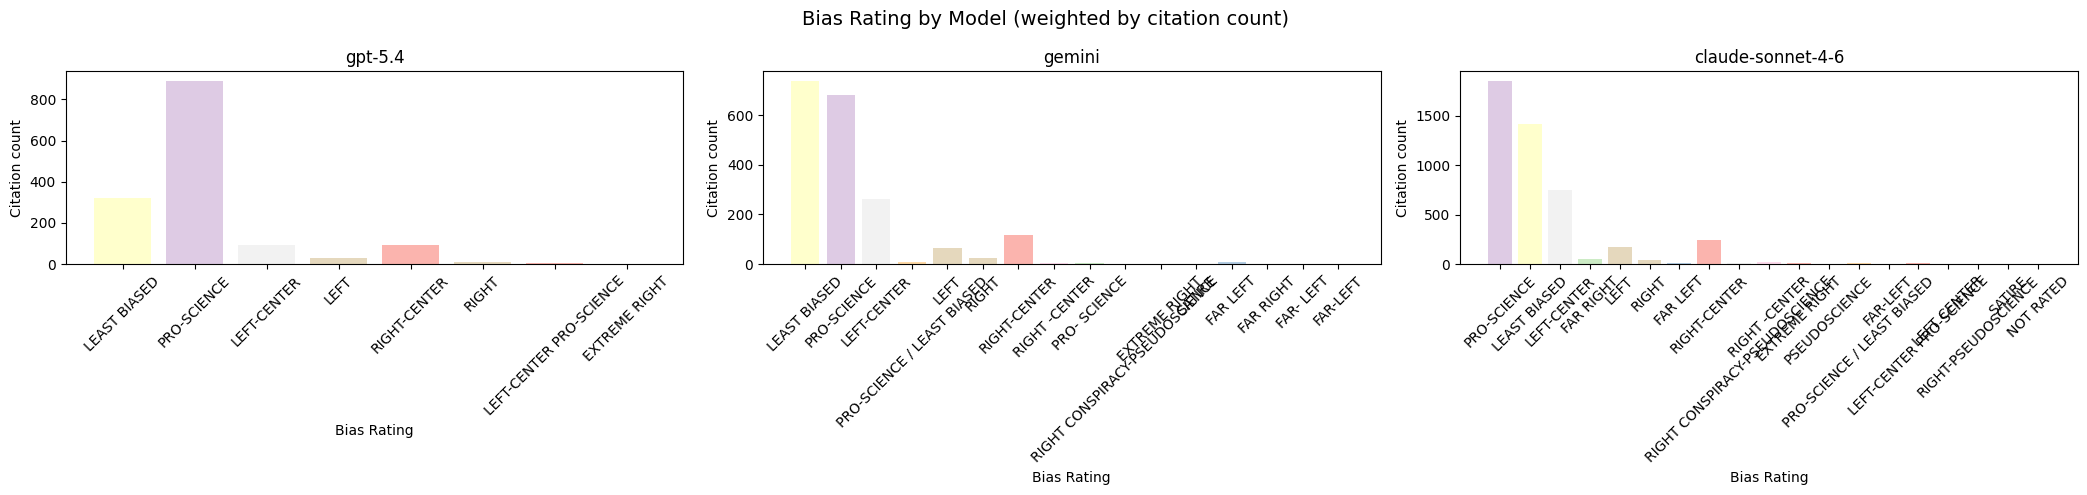

In [28]:
counts_by_credibility(data, score_column="Bias Rating")

In [41]:

CREDIBILITY_SCORE = {
    "HIGH CREDIBILITY": 2,
    "MEDIUM CREDIBILITY": 1,
    "LOW CREDIBILITY": 0,
}

def credibility_scores_per_model(mbfc_data, links_file="data/domains/prompt_id_links_clsf.json",
                                  annotations_file="data_prompts/man-annotated-train-high-risk.csv"):
    with open(links_file) as f:
        links = json.load(f)

    annotations = pd.read_csv(annotations_file)
    factual_prompts = set(annotations.loc[annotations["annotation"] == "Analytical", "prompt_id"])

    results = {}
    for model in links:
        total_count = 0
        weighted_sum = 0
        rating_counts = defaultdict(int)

        for prompt_id, urls in links[model].items():
            if prompt_id not in factual_prompts:
                continue
            for domain, url_data in urls.items():
                if domain not in mbfc_data:
                    continue
                info = mbfc_data[domain]
                if "MBFC Credibility Rating" not in info:
                    continue
                rating = info["MBFC Credibility Rating"]
                if rating not in CREDIBILITY_SCORE:
                    continue
                count = url_data["count"]
                weighted_sum += CREDIBILITY_SCORE[rating] * count
                total_count += count
                rating_counts[rating] += count

        results[model] = {
            "weighted_mean": weighted_sum / total_count if total_count else None,
            "pct_high": rating_counts["HIGH CREDIBILITY"] / total_count * 100 if total_count else 0,
            "pct_medium": rating_counts["MEDIUM CREDIBILITY"] / total_count * 100 if total_count else 0,
            "pct_low": rating_counts["LOW CREDIBILITY"] / total_count * 100 if total_count else 0,
            "total_citations": total_count,
        }

    return results


In [42]:

scores = credibility_scores_per_model(data)

header = f"{'Model':<25} {'% High':>8} {'% Medium':>10} {'% Low':>7} {'Total Citations':>16}"
print(header)
print("-" * len(header))
for model, s in scores.items():
    print(f"{model:<25} {s['pct_high']:>7.1f}% {s['pct_medium']:>9.1f}% {s['pct_low']:>6.1f}% {s['total_citations']:>16,}")


Model                       % High   % Medium   % Low  Total Citations
----------------------------------------------------------------------
gpt-5.4                      75.8%      22.6%    1.5%              778
gemini                       70.1%      25.7%    4.1%              747
claude-sonnet-4-6            71.7%      24.3%    4.0%            2,366
